In [1]:
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
model = joblib.load('model/model_rf.joblib')
model

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       n_estimators=200, random_state=0)

In [3]:
feature_importance = pd.DataFrame({
    'feature_name': model.feature_names_in_,
    'feature_importance': model.feature_importances_,
})

feature_importance.sort_values(
    by = 'feature_importance', 
    ascending = False,
    inplace = True
)
feature_importance

,feature_name,feature_importance
0,fnlwgt,0.233444
4,age-group,0.082858
6,education-num,0.078849
16,marital-status_married-civ-spouse,0.064180
1,capitalgain,0.063269
...,...,...
115,native-country_outlying-us(guam-usvi-etc),0.000022
60,native-country-code_HND,0.000015
103,native-country_honduras,0.000007
102,native-country_holand-netherlands,0.000003


In [4]:
print(feature_importance.head(20)) 

                         feature_name  feature_importance
0                              fnlwgt            0.233444
4                           age-group            0.082858
6                       education-num            0.078849
16  marital-status_married-civ-spouse            0.064180
1                         capitalgain            0.063269
5                        hoursperweek            0.052289
3                           education            0.045678
18       marital-status_never-married            0.037343
35               relationship_husband            0.032260
38             relationship_own-child            0.019555
2                         capitalloss            0.017890
24         occupation_exec-managerial            0.016003
36         relationship_not-in-family            0.015936
30          occupation_prof-specialty            0.014674
46                         sex_female            0.013053
9                   workclass_private            0.012896
40            

/tmp/ipykernel_1390/3751704783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


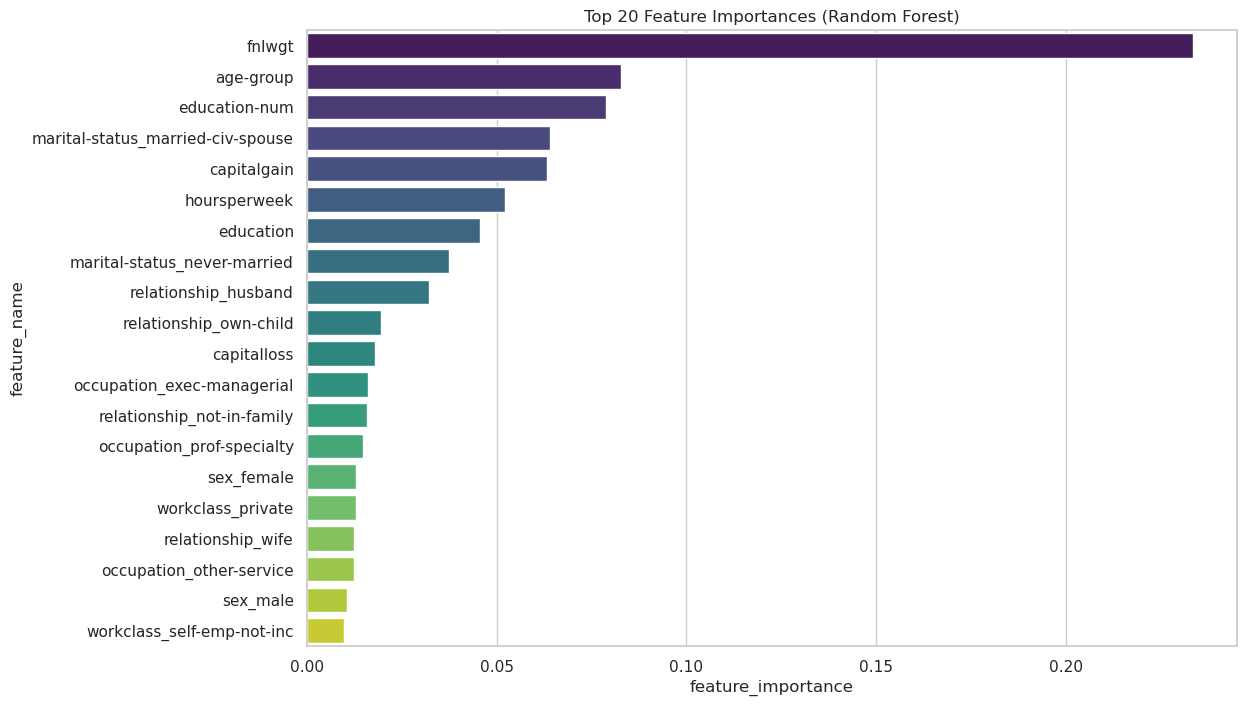

In [5]:
sns.set(style='whitegrid', rc={'figure.figsize': (12, 8)})
sns.barplot(
    x='feature_importance',
    y='feature_name',
    data=feature_importance.head(20),  # แสดงเฉพาะ top 20
    palette='viridis'
)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.show()

In [6]:
feature_importance.to_csv('./model/feature_importance_rf.csv', index=False)